<a href="https://colab.research.google.com/github/thomashooks53/DS-4002/blob/spring-2026_section-001/Hotdog_Analysis_Visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone -b spring-2026_section-001 https://github.com/thomashooks53/DS-4002.git

Cloning into 'DS-4002'...
remote: Enumerating objects: 983, done.
remote: Counting objects: 100% (324/324), done.
remote: Compressing objects: 100% (179/179), done.
remote: Total 983 (delta 270), reused 145 (delta 145), pack-reused 659 (from 3)
Receiving objects: 100% (983/983), 5.42 MiB | 22.29 MiB/s, done.
Resolving deltas: 100% (533/533), done.


In [2]:
import pandas as pd

df = pd.read_excel("/content/DS-4002/hot-dog-survey-data/Hotdog Survey (Responses).xlsx")

df.to_csv("hotdog_data.csv", index=False)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/DS-4002/hot-dog-survey-data/hotdog_data.csv")

df["Is a Hotdog a Sandwich?"].value_counts()


,count
Is a Hotdog a Sandwich?,
No,115
Yes,75


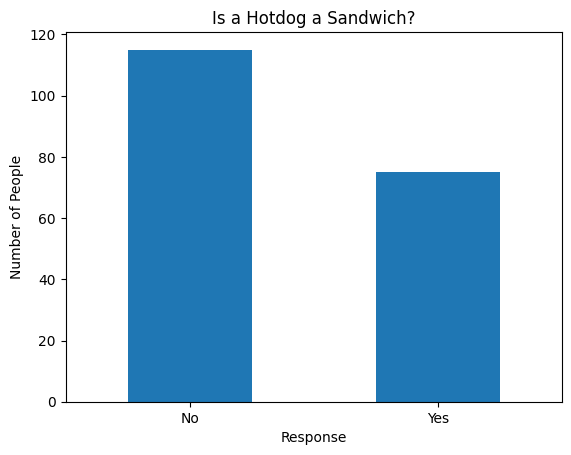

In [5]:
counts = df["Is a Hotdog a Sandwich?"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.xlabel("Response")
plt.ylabel("Number of People")
plt.xticks(rotation=0)
plt.title("Is a Hotdog a Sandwich?")
plt.show()

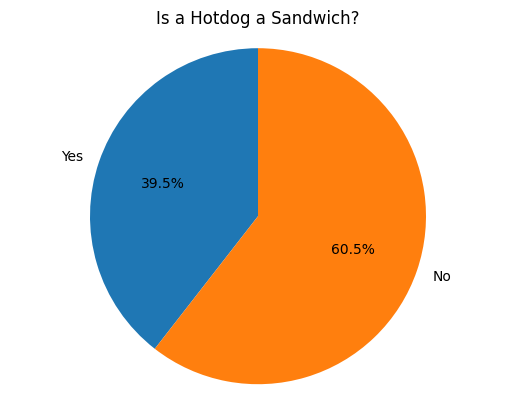

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/DS-4002/hot-dog-survey-data/hotdog_data.csv")

counts = (
    df["Is a Hotdog a Sandwich?"]
    .value_counts()
    .reindex(["Yes", "No"])
)

plt.figure()
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Is a Hotdog a Sandwich?")
plt.axis("equal")  # makes the pie a circle
plt.show()

<Figure size 640x480 with 0 Axes>

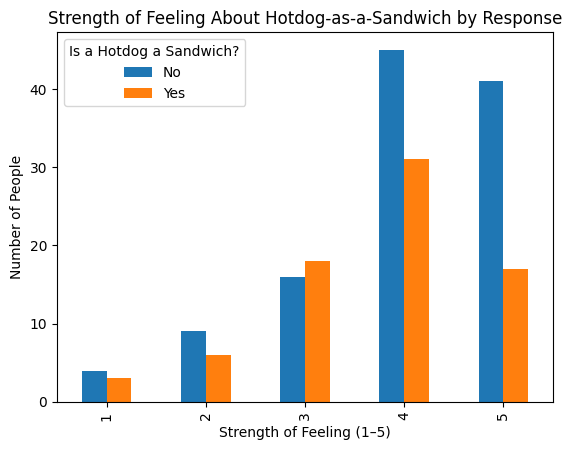

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/DS-4002/hot-dog-survey-data/hotdog_data.csv")

counts = pd.crosstab(
    df["How strongly do you feel about your previous answer?"],
    df["Is a Hotdog a Sandwich?"]
)

counts = counts.reindex([1, 2, 3, 4, 5])

plt.figure()
counts.plot(kind="bar", stacked=False)
plt.xlabel("Strength of Feeling (1–5)")
plt.ylabel("Number of People")
plt.title("Strength of Feeling About Hotdog-as-a-Sandwich by Response")
plt.show()



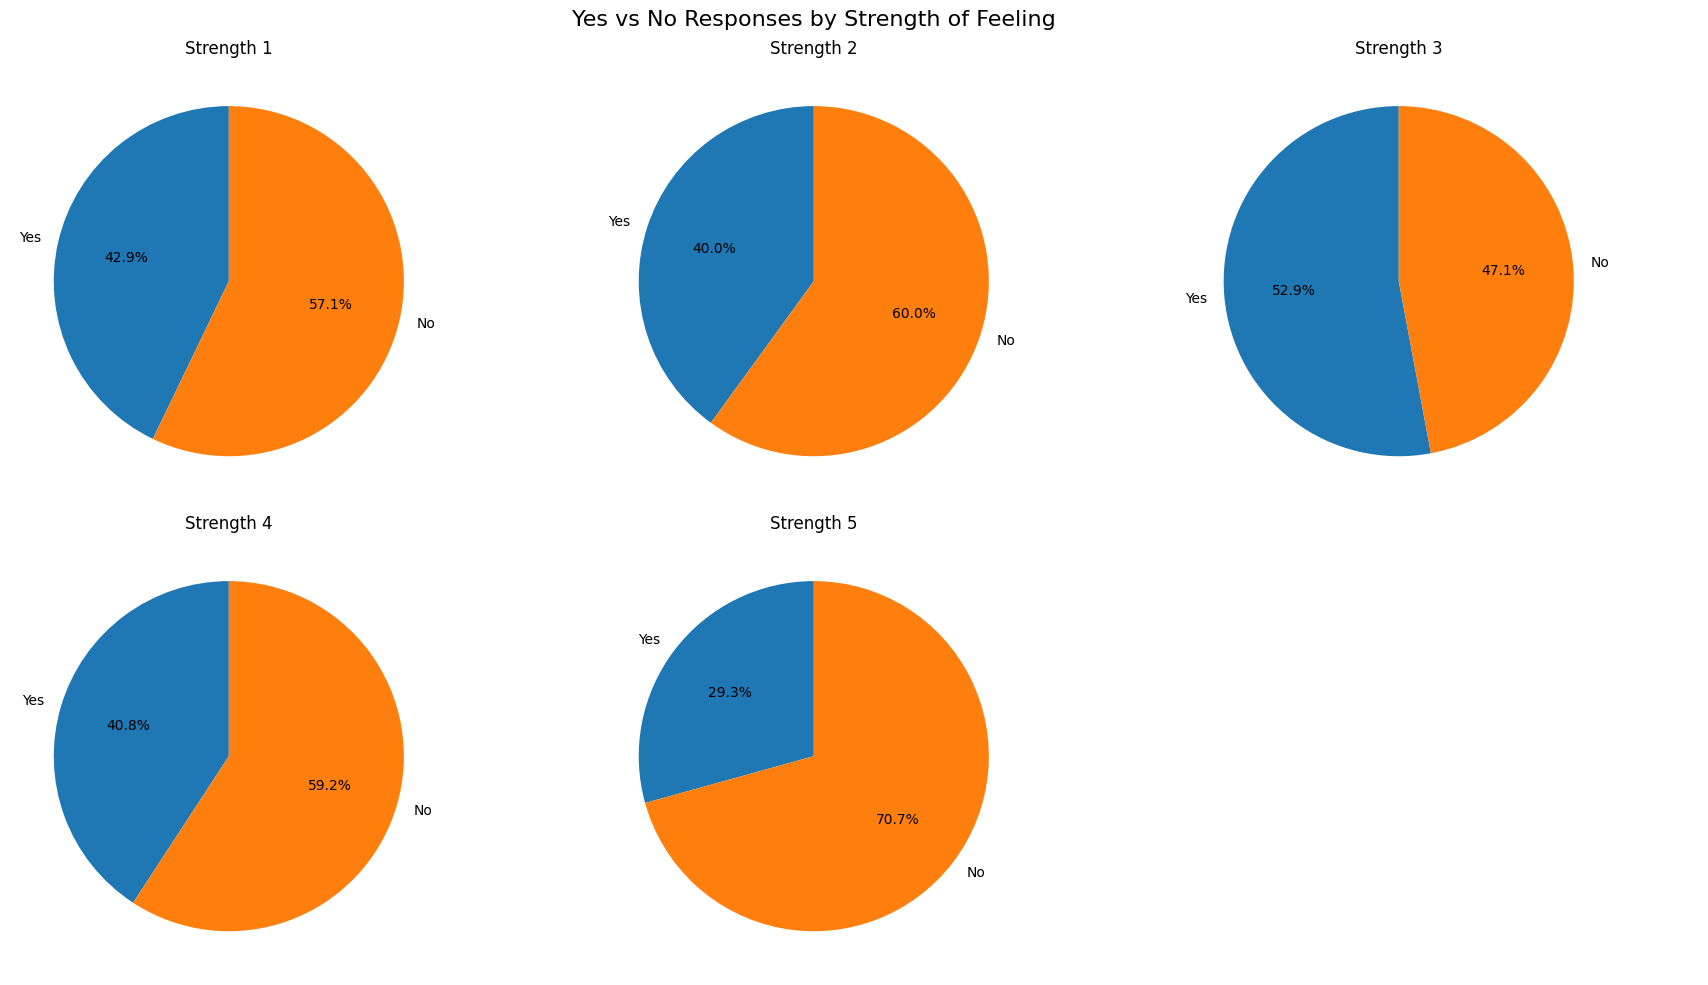

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/DS-4002/hot-dog-survey-data/hotdog_data.csv")

df["How strongly do you feel about your previous answer?"] = df[
    "How strongly do you feel about your previous answer?"
].astype(int)

strength_levels = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, strength in enumerate(strength_levels):
    subset = df[df["How strongly do you feel about your previous answer?"] == strength]
    counts = subset["Is a Hotdog a Sandwich?"].value_counts().reindex(["Yes", "No"])

    axes[i].pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#1f77b4", "#ff7f0e"]  # Optional: consistent colors
    )
    axes[i].set_title(f"Strength {strength}")

axes[-1].axis('off')

plt.suptitle("Yes vs No Responses by Strength of Feeling", fontsize=16)
plt.tight_layout()
plt.show()


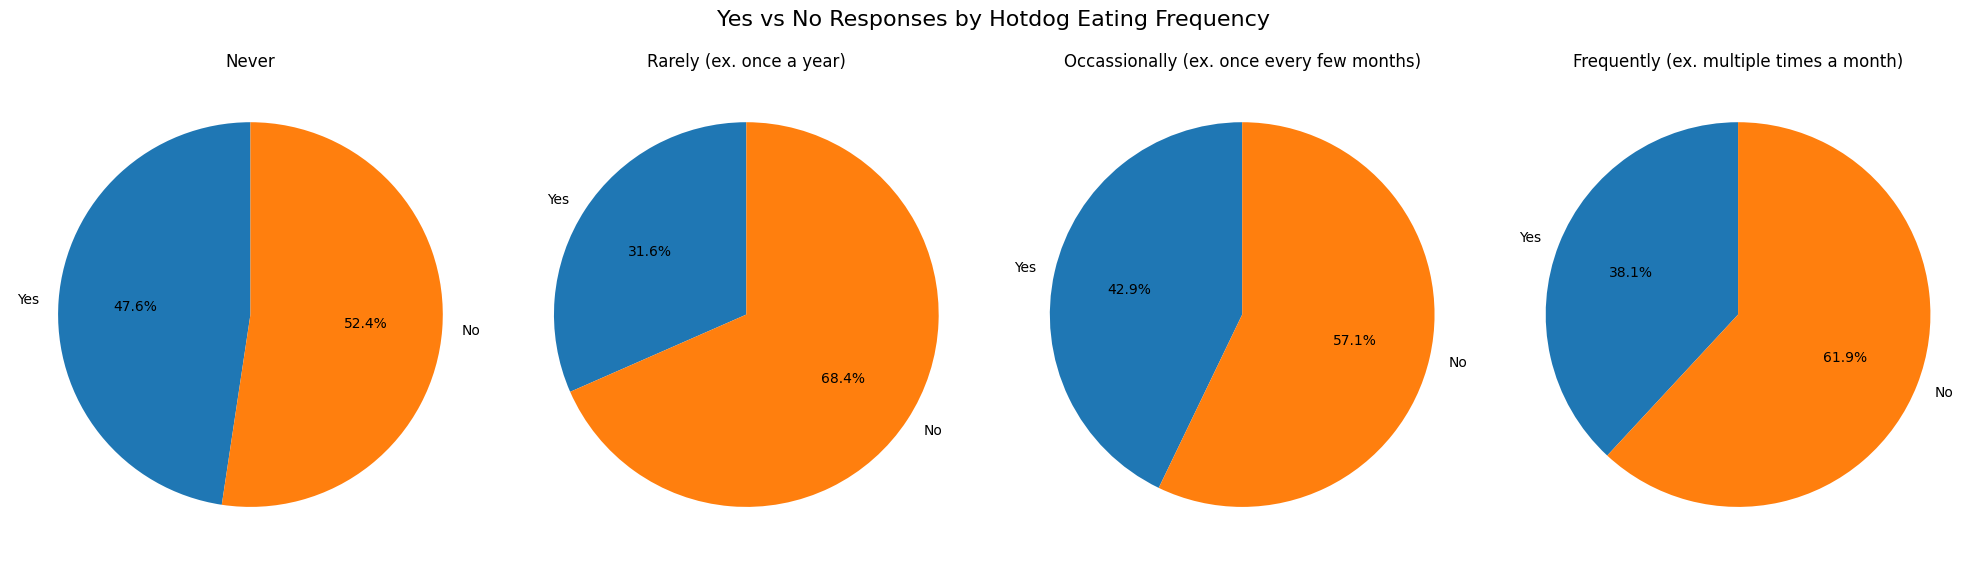

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/DS-4002/hot-dog-survey-data/hotdog_data.csv")

frequencies = [
    "Never",
    "Rarely (ex. once a year)",
    "Occassionally (ex. once every few months)",
    "Frequently (ex. multiple times a month)"
]

non_empty = [f for f in frequencies if not df[df["How frequently do you eat hot dogs?"] == f].empty]

fig, axes = plt.subplots(1, len(non_empty), figsize=(5*len(non_empty), 6))
if len(non_empty) == 1:
    axes = [axes]

for i, freq in enumerate(non_empty):
    subset = df[df["How frequently do you eat hot dogs?"] == freq]
    counts = subset["Is a Hotdog a Sandwich?"].value_counts().reindex(["Yes", "No"]).fillna(0)

    axes[i].pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#1f77b4", "#ff7f0e"]
    )
    axes[i].set_title(freq)

plt.suptitle("Yes vs No Responses by Hotdog Eating Frequency", fontsize=16)
plt.tight_layout()
plt.show()


In [19]:
import pandas as pd

df = pd.read_csv("/content/DS-4002/hot-dog-survey-data/hotdog_data.csv")

gender_counts = df["What is your Gender Identity?"].value_counts()
print(gender_counts)

What is your Gender Identity?
Woman                102
Man                   78
Nonbinary              8
Prefer not to say      2
Name: count, dtype: int64


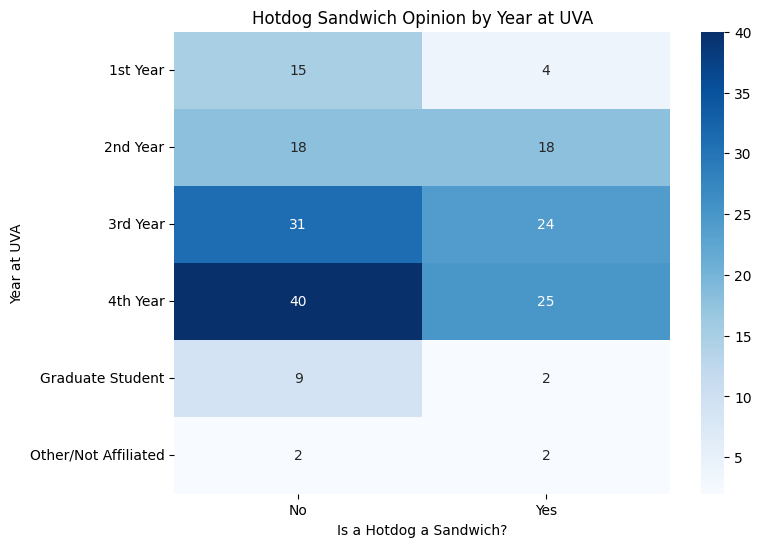

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/DS-4002/hot-dog-survey-data/hotdog_data.csv")

counts = pd.crosstab(df["Year at UVA"], df["Is a Hotdog a Sandwich?"])

plt.figure(figsize=(8,6))
sns.heatmap(
    counts,
    annot=True,          # show the counts on each cell
    fmt="d",             # integer format
    cmap="Blues"         # color map
)
plt.title("Hotdog Sandwich Opinion by Year at UVA")
plt.ylabel("Year at UVA")
plt.xlabel("Is a Hotdog a Sandwich?")
plt.show()


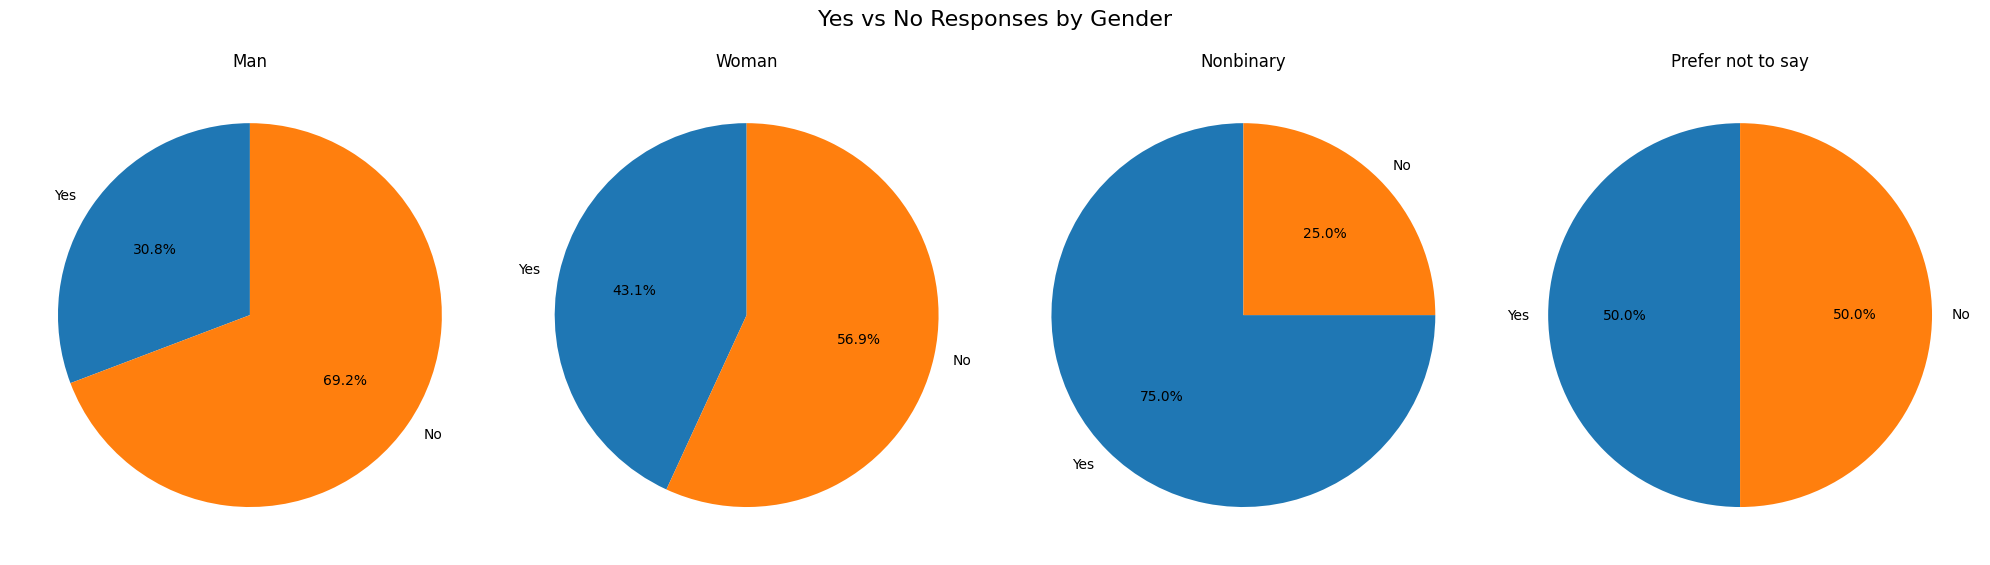

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("/content/DS-4002/hot-dog-survey-data/hotdog_data.csv")

# Get all unique genders
genders = df["What is your Gender Identity?"].unique()

# Create 1 row, N columns (number of genders)
fig, axes = plt.subplots(1, len(genders), figsize=(5*len(genders), 6))

# Flatten axes in case of single gender
if len(genders) == 1:
    axes = [axes]

# Colors for consistency
colors = ["#1f77b4", "#ff7f0e"]  # Yes = blue, No = orange

for i, gender in enumerate(genders):
    subset = df[df["What is your Gender Identity?"] == gender]

    # Count Yes/No, fill missing with 0
    counts = subset["Is a Hotdog a Sandwich?"].value_counts().reindex(["Yes", "No"]).fillna(0)

    # Handle empty subsets
    if counts.sum() == 0:
        axes[i].text(0.5, 0.5, "No responses", ha='center', va='center', fontsize=12)
        axes[i].axis('off')
    else:
        axes[i].pie(
            counts,
            labels=counts.index,
            autopct="%1.1f%%",
            startangle=90,
            colors=colors
        )

    axes[i].set_title(gender)

plt.suptitle("Yes vs No Responses by Gender", fontsize=16)
plt.tight_layout()
plt.show()
